In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

sns.set_style("darkgrid")

In [2]:
src_dir = '../../data/perplexity/'

In [3]:
model_name = os.listdir(src_dir)[0]
model_name

'bert_base_42_train_1_orig'

In [4]:
def add_to_res_dict(res_dict, model, checkpoint, metric, score):
    res_dict['model'].append(model)
    res_dict['checkpoint'].append(checkpoint)
    res_dict['metric'].append(metric)
    res_dict['score'].append(score)

In [5]:
def score_model(src_path):
    scores_df = pd.read_csv(src_path)
    return scores_df['plausibility'].tolist(), scores_df['perplexity'].tolist()
    # avg_plausibility = scores_df['plausibility'].mean()
    # avg_perplexity = scores_df['perplexity'].mean()
    # return avg_plausibility, avg_perplexity

In [6]:
res_dict = {'model': [], 'checkpoint':[], 'metric': [], 'score':[]}

model_dir = os.path.join(src_dir, model_name)
for checkpoint_file_name in os.listdir(model_dir):
    
    checkpoint_num = int(checkpoint_file_name.split('-')[-1][:-4])
    checkpoint_path = os.path.join(model_dir, checkpoint_file_name)

    plausibility, perplexity = score_model(checkpoint_path)
    for pl, pp in zip(plausibility, perplexity):
        add_to_res_dict(res_dict, model_name, checkpoint_num, 'plausibility', pl)
        add_to_res_dict(res_dict, model_name, checkpoint_num, 'perplexity', pp)        
    # add_to_res_dict(res_dict, model_name, checkpoint_num, 'plausibility', plausibility)
    # add_to_res_dict(res_dict, model_name, checkpoint_num, 'perplexity', perplexity)

In [7]:
res_df = pd.DataFrame.from_dict(res_dict)

In [8]:
res_df

,model,checkpoint,metric,score
0,bert_base_42_train_1_orig,112000,plausibility,0.098898
1,bert_base_42_train_1_orig,112000,perplexity,161.475647
2,bert_base_42_train_1_orig,112000,plausibility,0.084509
3,bert_base_42_train_1_orig,112000,perplexity,160.563583
4,bert_base_42_train_1_orig,112000,plausibility,0.077835
...,...,...,...,...
7795,bert_base_42_train_1_orig,2800,perplexity,567.795898
7796,bert_base_42_train_1_orig,2800,plausibility,0.006544
7797,bert_base_42_train_1_orig,2800,perplexity,580.165649
7798,bert_base_42_train_1_orig,2800,plausibility,0.007253


In [9]:
for model in list(res_df['model'].unique()):
    model_df = res_df[res_df['model'] == model]
    vmin = model_df['score'].min()
    vmax = model_df['score'].max()

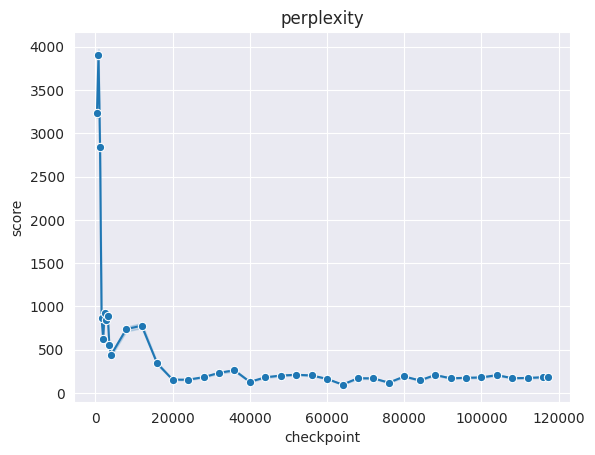

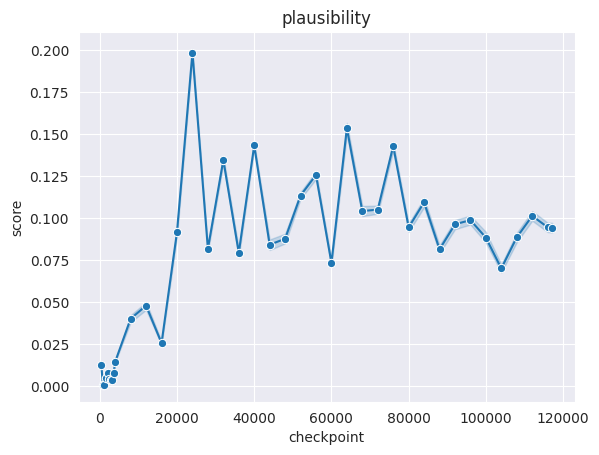

In [10]:
for metric in sorted(list(model_df['metric'].unique())):
    metric_df = model_df[model_df['metric'] == metric]
    
    plt.figure()
    sns.lineplot(data=metric_df, x='checkpoint', y='score', marker='o', legend=False)
    plt.title(f'{metric}')
    plt.show()